# Performing a Least Squares adjustment

This example shows how to perform an adjustment using GLLS for improving the prediction of an applicaiton when a set of relevant benchmarks are given. To do so, we select two benchmarks, being HMF001 and HMF002-001 to improve the prediction for another benchmark HMF002-002. The posterior response of benchmark HMF002-002 will then be compared to the experimental value to verify whether the discrepancy between measurement and calculation is lower.

### 1. Setup and Imports
First, we import `matplotlib` for figure customization and the `andalus` core package.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import sandy
from matplotlib.lines import Line2D

import andalus

NumExpr defaulting to 12 threads.


### 2. Reading Serpent Output
We use the `AssimilationSuite.from_yaml` method to easily load in a set of benchmarks / applicaitons and covariance information. 

For this example, we limit the assimilation to only U-235 and U-238.

In [2]:
assimilation_suite = andalus.AssimilationSuite.from_yaml("config.yaml")

Reading ../data/hmf001.ser_res.m
  - done
Reading ../data/hmf001.ser_sens0.m
  - done
Reading ../data/hmf002-001.ser_res.m
  - done
Reading ../data/hmf002-001.ser_sens0.m
  - done
Reading ../data/hmf002-002.ser_res.m
  - done
Reading ../data/hmf002-002.ser_sens0.m
  - done


### 3. Plotting Energy-Dependent Sensitivities
Let us inspect the sensitivity profiles for the different benchmarks and the application. Below, we focus on U-235 (ZAI 922350) for Fission (MT 18) and Capture (MT 102).

C:\Users\dhouben\Documents\andalus\src\andalus\sensitivity.py:235: PerformanceWarning: indexing past lexsort depth may impact performance.
  subset = self.loc[zai, pert]


[(100.0, 20000000.0)]

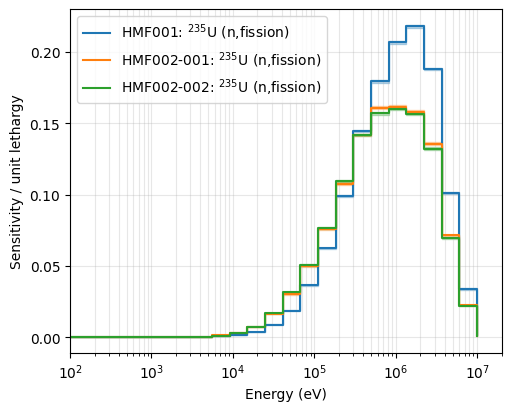

In [3]:
zais = [922350]  # U-235
perts = [18]  # Fission and Capture

fig, ax = plt.subplots(figsize=(5, 4), layout="constrained")

for benchmark in assimilation_suite.benchmarks:
    for zai in zais:
        for pert in perts:
            benchmark.s.plot_sensitivity(zais=[zai], perts=[pert], ax=ax)

assimilation_suite.applications["HMF002-002"].s.plot_sensitivity(zais=zais, perts=perts, ax=ax)

ax.set(
    xlim=(1e2, 2e7),
)

### 4. Analyze how similar the benchmarks are with respect to the application
We can calculate similarity coefficients which explain how much of the nuclear data uncertainties are shared between two systems. The similarity coefficient, also called the ck-similarity index, is calculated by:

$$
c_k=\frac{\text{Cov}(1,2)}{\sqrt(\text{Var}(1)\text{Var}(2))}
$$


In [4]:
# Print the ck-similarity matrix
assimilation_suite.ck_matrix()

,HMF001,HMF002-001,HMF002-002
HMF001,1.00000e+00,8.58986e-01,8.61173e-01
HMF002-001,8.58986e-01,1.00000e+00,9.99814e-01
HMF002-002,8.61173e-01,9.99814e-01,1.00000e+00


In [5]:
# Print the ck-similarity values for a specific target
assimilation_suite.ck_target("HMF002-002")

HMF001       8.61173e-01
HMF002-001   9.99814e-01
Name: HMF002-002, dtype: float64

We can see that HMF002-001 shares more than 99% of the nuclear data uncertainties, meaning that if we can the nuclear data uncertainties in HMF002-001, we will also target the nuclear data uncertainties in HMF002-002.

### 5. Perform assimilation

In [6]:
posterior_suite = assimilation_suite.glls()

In [7]:
posterior_suite.individual_chi_squared(nuclear_data=True)

HMF001       8.95987e-07
HMF002-001   2.26745e-04
Name: chi_squared, dtype: float64

In [8]:
chi_squared = pd.DataFrame(
    {
        "Prior": assimilation_suite.individual_chi_squared(nuclear_data=True),
        "Posterior": posterior_suite.individual_chi_squared(nuclear_data=True),
    }
)

[None, Text(0, 0.5, '$\\chi^2$'), Text(0.5, 0, 'Benchmark title')]

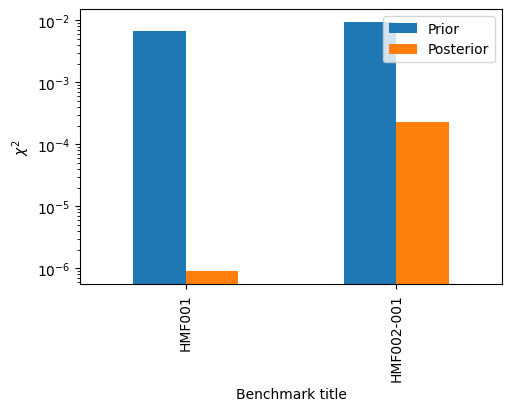

In [9]:
fig, ax = plt.subplots(figsize=(5, 4), layout="constrained")

chi_squared.plot.bar(ax=ax)

ax.set(yscale="log", ylabel=r"$\chi^2$", xlabel="Benchmark title")

<Axes: xlabel='Energy, eV', ylabel='Standard Deviation, %'>

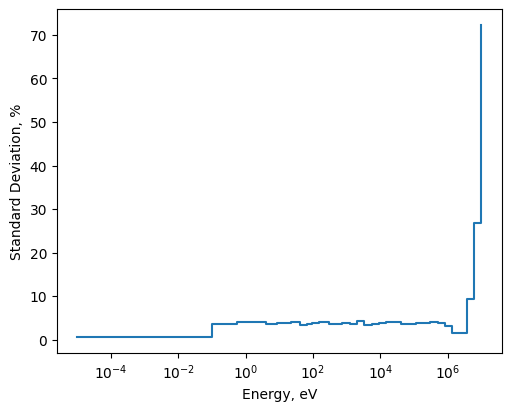

In [47]:
assimilation_suite.covariances.plot_uncertainty(zai=zai, mt=35018)

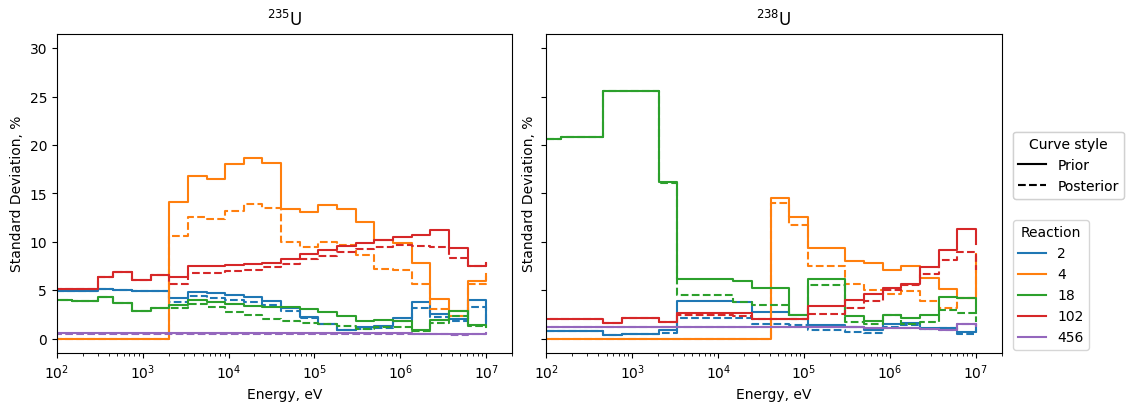

In [52]:
zais = [922350, 922380]  # U-235
mts = [2, 4, 18, 102, 456]  # Fission and Capture

fig, axs = plt.subplots(1, 2, figsize=(10, 4), layout="constrained", dpi=100, sharey=True)

colors = ["C0", "C1", "C2", "C3", "C4", "C5"]

for i, zai in enumerate(zais):
    ax = axs[i]
    for mt, color in zip(mts, colors):
        assimilation_suite.covariances.plot_uncertainty(zai=zai, mt=mt, ax=ax, color=color, label=f"Prior MT{mt}")
        posterior_suite.covariances.plot_uncertainty(
            zai=zai, mt=mt, ax=ax, color=color, label=f"Posterior MT{mt}", linestyle="--"
        )

    ax.set(
        title=f"{sandy.zam.zam2latex(zai)}",
        xlim=(1e2, 2e7),
    )

# Legend 1: linestyle -> prior/posterior
style_handles = [
    Line2D([0], [0], color="black", linestyle="-", label="Prior"),
    Line2D([0], [0], color="black", linestyle="--", label="Posterior"),
]
style_legend = fig.legend(
    handles=style_handles,
    loc="center left",
    bbox_to_anchor=(1, 0.6),
    ncol=1,
    title="Curve style",
)

# Legend 2: color -> MT
mt_handles = [Line2D([0], [0], color=color, linestyle="-", label=f"{mt}") for mt, color in zip(mts, colors)]
fig.legend(
    handles=mt_handles,
    loc="center left",
    bbox_to_anchor=(1, 0.3),
    ncol=1,
    title="Reaction",
)

fig.add_artist(style_legend)

plt.show()

In [23]:
assimilation_suite.propagate_nuclear_data_uncertainty()

HMF001       1.34060e-02
HMF002-001   1.41786e-02
HMF002-002   1.43740e-02
Name: uncertainty_from_nuclear_data, dtype: float64

Now let us plot the prior and posterior responses with their prediction uncertainty which comes from nuclear data. The last system was not included in the assimilation. The experimental measurement for HMF002-002 is 1.00000 +/- 0.00300, so our new prediction is better at predicting the behaviour of this new experiment. 

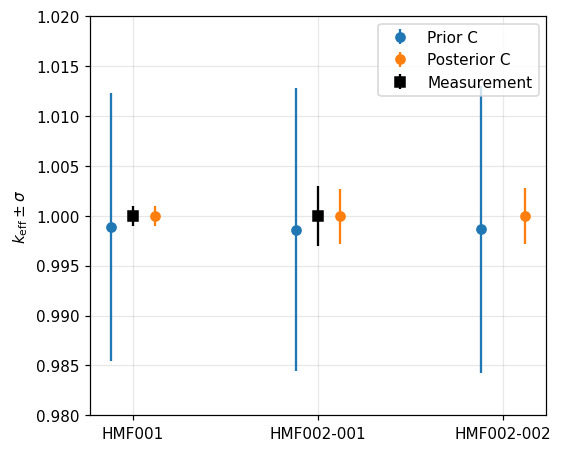

In [46]:
x_all = list(range(len(assimilation_suite.titles)))
x_prior = [x - 0.12 for x in x_all]
x_post = [x + 0.12 for x in x_all]

prior_dnd = assimilation_suite.propagate_nuclear_data_uncertainty()
post_dnd = posterior_suite.propagate_nuclear_data_uncertainty()

m_b = list(assimilation_suite.benchmarks.m)
dm_b = list(assimilation_suite.benchmarks.dm)

fig, ax = plt.subplots(figsize=(5, 4), layout="constrained", dpi=110)

# Panel 1: absolute keff
ax.errorbar(x_prior, assimilation_suite.c, yerr=prior_dnd, fmt="o", color="C0", label="Prior C")
ax.errorbar(x_post, posterior_suite.c, yerr=post_dnd, fmt="o", color="C1", label="Posterior C")
ax.errorbar(assimilation_suite.benchmarks.titles, m_b, yerr=dm_b, fmt="s", color="k", label="Measurement")

ax.set(
    ylim=(0.98, 1.02),
)
ax.set_xticks(x_all)
ax.set_xticklabels(assimilation_suite.titles, rotation=0, ha="center")
ax.set_ylabel(r"$k_{\mathrm{eff}} \pm \sigma$")
ax.grid(alpha=0.3)
ax.legend()


plt.show()